# Simple 2D inversion test

- Import the required modules

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import covmats
import pypcga
from pypcga._utils import NDArrayFloat
import logging
import nested_grid_plotter as ngp

- Apply so nice parameters for the plots

In [2]:
ngp.apply_nice_default_rc_params()

- Create some logging instances to illustrate how to use them in a complex workflow

In [3]:
# Create loggers
main_logger = logging.getLogger("main")
main_logger.setLevel(logging.INFO)
pcga_logger = logging.getLogger("PCGA")
pcga_logger.setLevel(logging.INFO)
main_logger.info("This is the main logger")
pcga_logger.info("This is the PCGA logger")

Let's use an example provided by `covmats`. Here, the prior covariance matrix, $\mathbf{C}_{\mathrm{prior}}$ is represented as a sparse factorization of its inverse $\mathbf{C}_{\mathrm{prior}}^{-1}$ with $\mathbf{LDL}^{\mathrm{T}} = \mathbf{PC}_{\mathrm{prior}}^{-1}\mathbf{P}^{\mathrm{T}}$. This is wrapped in the `covmats.CovViaSparsePrecisionCholesky` instance we create:

In [4]:
cov_prior = covmats.CovViaSparsePrecisionCholesky(
    covmats.load_precision_example_4225x_SCF()
)
cov_prior

<4225x4225 CovViaSparsePrecisionCholesky with dtype=float64>

The covariance matrix has shape (4225, 4225) , let's define a square domain (65, 65) and perform a non conditional simulation using our prior. We set a mean @ 50 and display it:

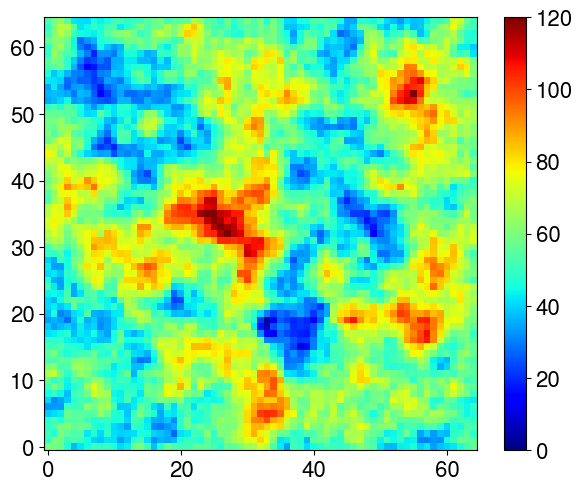

In [5]:
nx = ny = int(np.sqrt(cov_prior.shape[0]))

# Non conditonal simulation -> change the random state to obtain a different field
simu_ = cov_prior.sample_mvnormal(shape=(1,), random_state=2026).reshape(ny, nx).T
mean= 50.0
s_ref = np.abs(simu_ + mean)

plt.imshow(
    s_ref.T,
    origin="lower",
    cmap=plt.get_cmap("jet"),
    aspect="equal",
    vmin=0.0,
    vmax=120,
)
plt.colorbar()

- Define a very simple non linear forward model (just a simple static smoohting, no timea dependance here) and produce a reference field from which observations will be sampled.

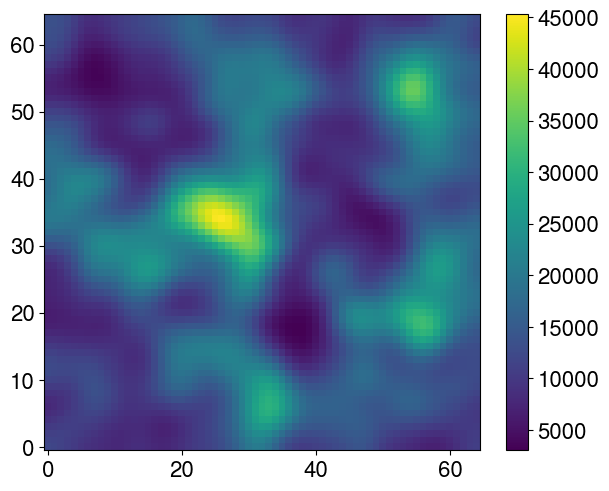

In [6]:
def forward_model(x) -> NDArrayFloat:
    return sp.ndimage.gaussian_filter(4.0 * x**2, sigma=2.0)

d_ref = forward_model(s_ref)

plt.imshow(
    d_ref.T,
    origin="lower",
    aspect="equal",
)
plt.colorbar()

Create a second simulation from the prior that will be the starting point for the parameters estimation.

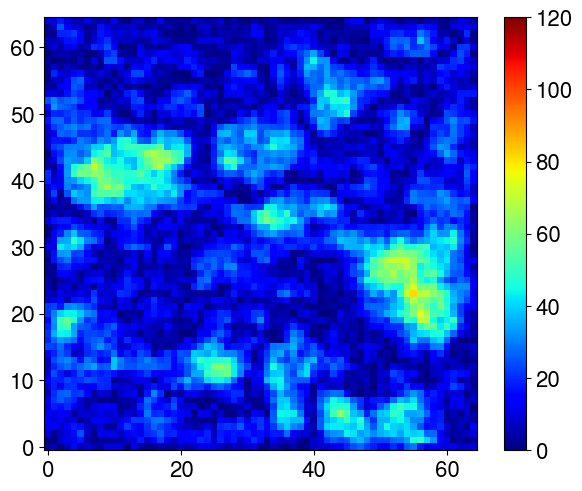

In [7]:
s_init = np.abs(cov_prior.sample_mvnormal(shape=(1,), random_state=15653).reshape(ny, nx).T)

plt.imshow(
    s_init.T,
    origin="lower",
    cmap=plt.get_cmap("jet"),
    aspect="equal",
    vmin=0.0,
    vmax=120,
)
plt.colorbar()

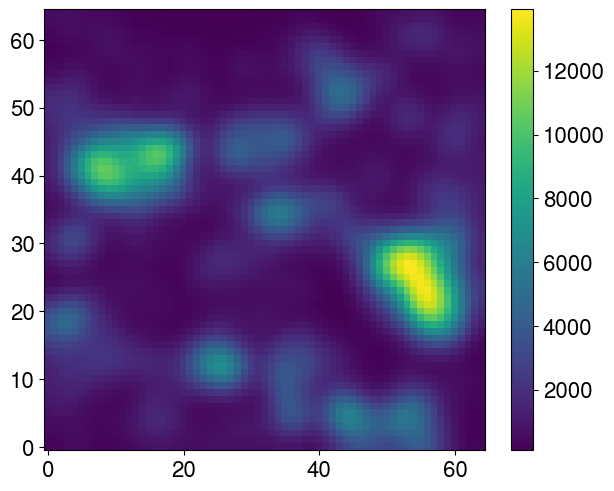

In [8]:
d_init = forward_model(s_init)

plt.imshow(
    d_init.T,
    origin="lower",
    aspect="equal",
)
plt.colorbar()

Create a sampling function that uses 5% of the available data

In [9]:
percent_of_values = 0.05

def sample_d(d) -> NDArrayFloat:
    return d.ravel("F")[:: int(d.size / (percent_of_values * 1000))]

obs = sample_d(d_ref)
obs.shape

(51,)

In [10]:
# 10% error on the observations
cov_obs = covmats.CovViaDiagonal(
    (np.ones(obs.shape) * (np.max(obs) - np.min(obs)) * 0.1) ** 2
)

- Factorize the covariance matrix

In [11]:
eig_mat = covmats.eigen_factorize_cov_mat(cov_prior, n_pc=50)

assert eig_mat.n_pts == 4225

- Create a forward model

In [12]:
def forward_model_wrapper(s_ensemble, *args, **kargs) -> NDArrayFloat:
    d_pred = np.zeros((obs.size, s_ensemble.shape[1]))
    for i in range(s_ensemble.shape[1]):
        # use preconditionning
        res = forward_model(s_ensemble[:, i].reshape(nx, ny, order="F"))
        d_pred[:, i] = sample_d(res)
    return d_pred


# test
s_ens = np.vstack([s_ref.ravel("F"), s_init.ravel("F")]).T
assert s_ens.shape == (nx * ny, 2)

d_pred = forward_model_wrapper(s_ens)
assert d_pred.shape == (obs.size, 2)

np.testing.assert_almost_equal(d_pred[:, 0], obs)

- Perturb observations

In [13]:
obs_perturb = (
    obs + cov_obs.sample_mvnormal([1], random_state=np.random.default_rng(2151))[0]
)

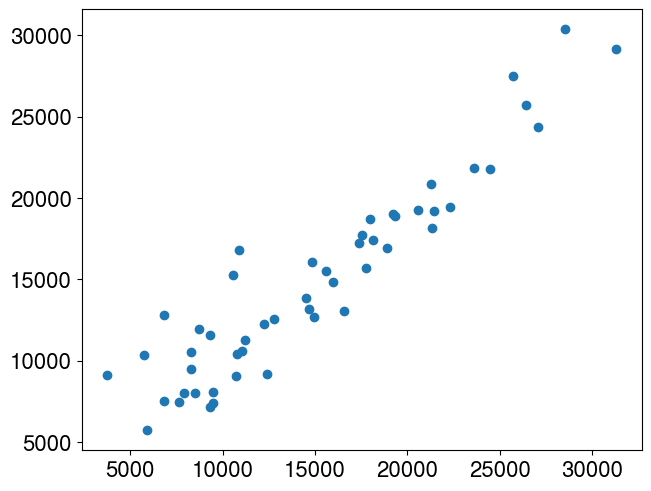

In [14]:
plt.scatter(obs_perturb, obs)


- Create the PCGA instance

In [ ]:
solver = pypcga.PCGA(
    s_init=s_init.ravel("F"),
    obs=obs_perturb,
    cov_obs=cov_obs,
    forward_model=forward_model_wrapper,
    Q=eig_mat,
    maxiter=5,
    is_lm=True,
    is_direct_solve=False,
    prior_s_var=None,
    random_state=2026,
    logger=pcga_logger,
)

INFO:PCGA:##### PCGA Inversion #####
INFO:PCGA:##### 1. Initialize forward and inversion parameters
INFO:PCGA:------------ Inversion Parameters -------------------------
INFO:PCGA:  Number of unknowns                    : 4225
INFO:PCGA:  Number of observations                : 51
INFO:PCGA:  Number of principal components (n_pc) : 50
INFO:PCGA:  Maximum Gauss-Newton iterations       : 5
INFO:PCGA:  Machine eps (delta = sqrt(eps))       : 1e-08
INFO:PCGA:  Minimum model change (restol)         : 0.01
INFO:PCGA:  Minimum obj fun change (ftol)         : 0.0
INFO:PCGA:  Target obj fun (ftarget)              : None
INFO:PCGA:  Levenberg-Marquardt (is_lm)           : True
INFO:PCGA:  Minimum LM solution (lm_smin)         : None
INFO:PCGA:  Maximum LM solution (lm_smax)         : None
INFO:PCGA:  Maximum LM iterations (max_it_lm)     : 16
INFO:PCGA:  Line search                           : False
INFO:PCGA:-----------------------------------------------------------


In [16]:
assert solver.s_dim == nx * ny
assert solver.d_dim == obs.size

In [17]:
solver.drift.mat

array([[0.01538462],
       [0.01538462],
       [0.01538462],
       ...,
       [0.01538462],
       [0.01538462],
       [0.01538462]], shape=(4225, 1))

In [18]:
solver.prior_s_var

array([0.60196488, 2.27980911, 4.68797668, ..., 4.68797668, 2.27980911,
       0.60196488], shape=(4225,))

In [19]:
solver.cov_obs

<51x51 CovViaDiagonal with dtype=float64>

In [20]:
s_hat, simul_obs, post_diagv, iter_best = solver.run()

INFO:PCGA:##### 2. Start PCGA Inversion #####
INFO:PCGA:-- evaluate initial solution
INFO:PCGA:** LS objfun 0.5 (obs. diff.)^T R^{-1}(obs. diff.)              : 9.224e+02
INFO:PCGA:** norm LS objfun 0.5 / nobs (obs. diff.)^T R^{-1}(obs. diff.)  : 1.809e+01
INFO:PCGA:** RMSE (norm(obs. diff.)/sqrt(nobs))                           : 1.483e+04
INFO:PCGA:** norm RMSE (norm(obs. diff./sqrtR)/sqrt(nobs))                : 6.014e+00
INFO:PCGA:** objective function (no beta)                                 : 9.360e+02
INFO:PCGA:
INFO:PCGA:***** Iteration 1 ******
INFO:PCGA:computed Jacobian-Matrix products in : 1.519e-02 s
INFO:PCGA:Use Krylov subspace iterative solver for saddle-point (cokrigging) system
INFO:PCGA:Preconditioner construction using Generalized Eigen-decomposition
INFO:PCGA:Time for data covarance construction :1.87e-02 sec
INFO:PCGA:-- Number of iterations for gmres 1
INFO:PCGA:-- Number of iterations for gmres 11
INFO:PCGA:-- Number of iterations for gmres 16
INFO:PCGA:-- Numb

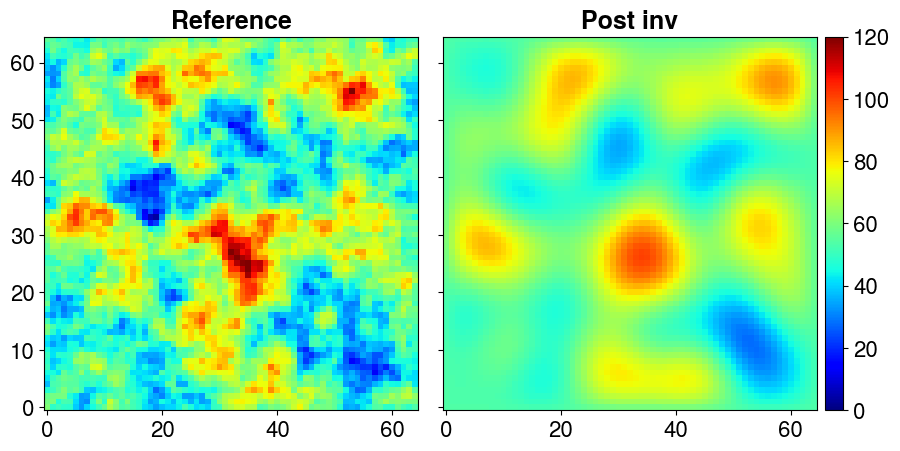

In [21]:
import nested_grid_plotter as ngp

plotter = ngp.Plotter(
    plt.figure(figsize=(9.0, 4.4), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["ref", "inv"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={"Reference": s_ref.T, "Post inv": s_hat.reshape(nx, ny, order="F").T},
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("jet"),
        aspect="equal",
        vmin=0.0,
        vmax=120,
    ),
    cbar_kwargs=dict(pad=0.01),
)

# Get the covariance

Le solver retourne également une estimation de la variance à posteriori sous la forme d'un vecteur de dimension Ns. Il est également possible d'obtenir une approximation low-rank de la matrice de covariance à posteriori. Le nombre de composante principales ainsi que certains paramètres comme l'inflation etc peuvent être modifié si nécessaire. Dans le cas présent, nous construsions la matrice avec 25 puis avec 50 composantes principales.

In [22]:
post_cov_dense = solver.get_dense_post_cov()
post_cov_25_pc = solver.get_eigen_post_cov(n_pc=25)
post_cov_50_pc = solver.get_eigen_post_cov(n_pc=50)

INFO:PCGA:Preconditioner construction using Generalized Eigen-decomposition
INFO:PCGA:Time for data covarance construction :2.44e-02 sec
INFO:PCGA:Preconditioner construction using Generalized Eigen-decomposition
INFO:PCGA:Time for data covarance construction :3.79e-02 sec
INFO:PCGA:Preconditioner construction using Generalized Eigen-decomposition
INFO:PCGA:Time for data covarance construction :3.33e-02 sec


On peut voir que plus le nombre de PC est important, plus l'approximation est correcte

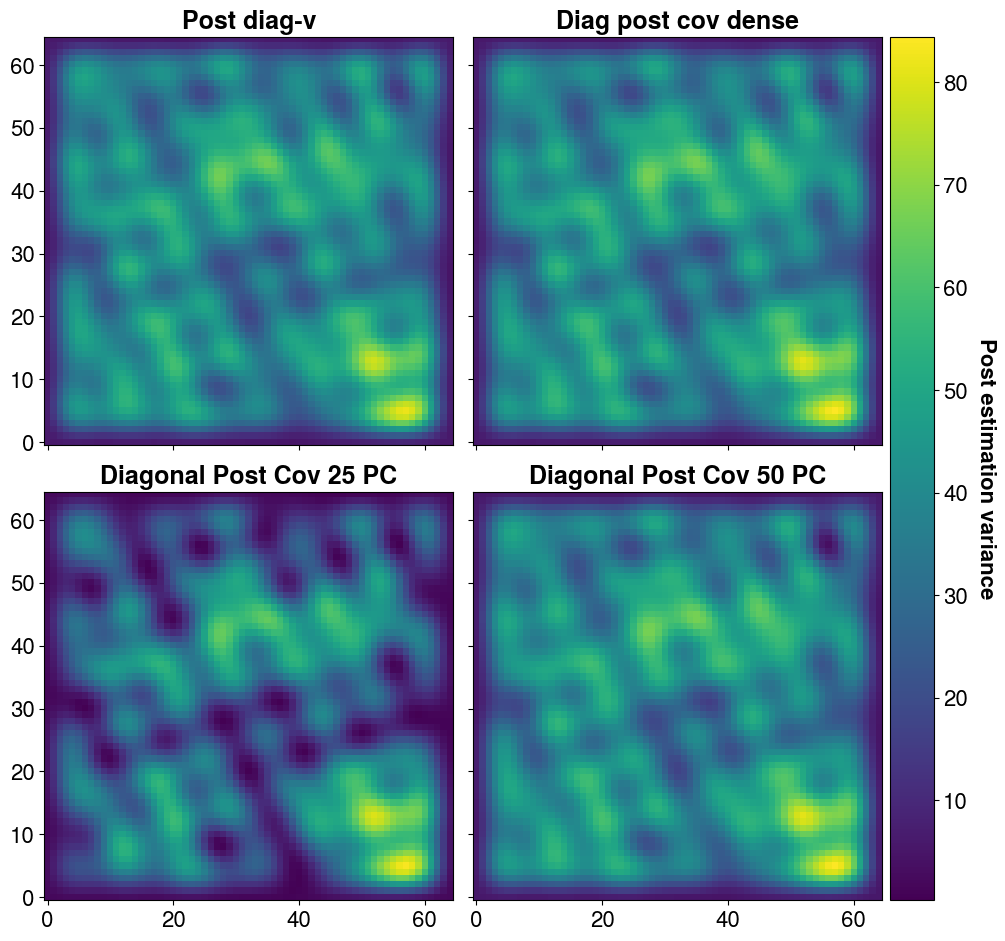

In [23]:
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 9.3), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["diag", "dense"],["25pc", "50pc"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        "Post diag-v": post_diagv.reshape(nx, ny, order="F").T,
        "Diag post cov dense": np.diagonal(post_cov_dense).reshape(nx, ny, order="F").T,
        "Diagonal Post Cov 25 PC": post_cov_25_pc.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
        "Diagonal Post Cov 50 PC": post_cov_50_pc.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("viridis"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01),
    cbar_title="Post estimation variance"
)

L'intéret de la matrice de covariance à postriori est qu'il est possible de produire des réalisations:

In [24]:
# make 200 posterior realizations => we sample from post_cov_50_pc and add the results to s_hat, our inversed parameter vector
post_samples = (
    s_hat.T
    + post_cov_50_pc.sample_mvnormal(shape=(200,), random_state=solver.random_state)
).T
post_samples.shape

(4225, 200)

- Let's plot the first 25 realizations

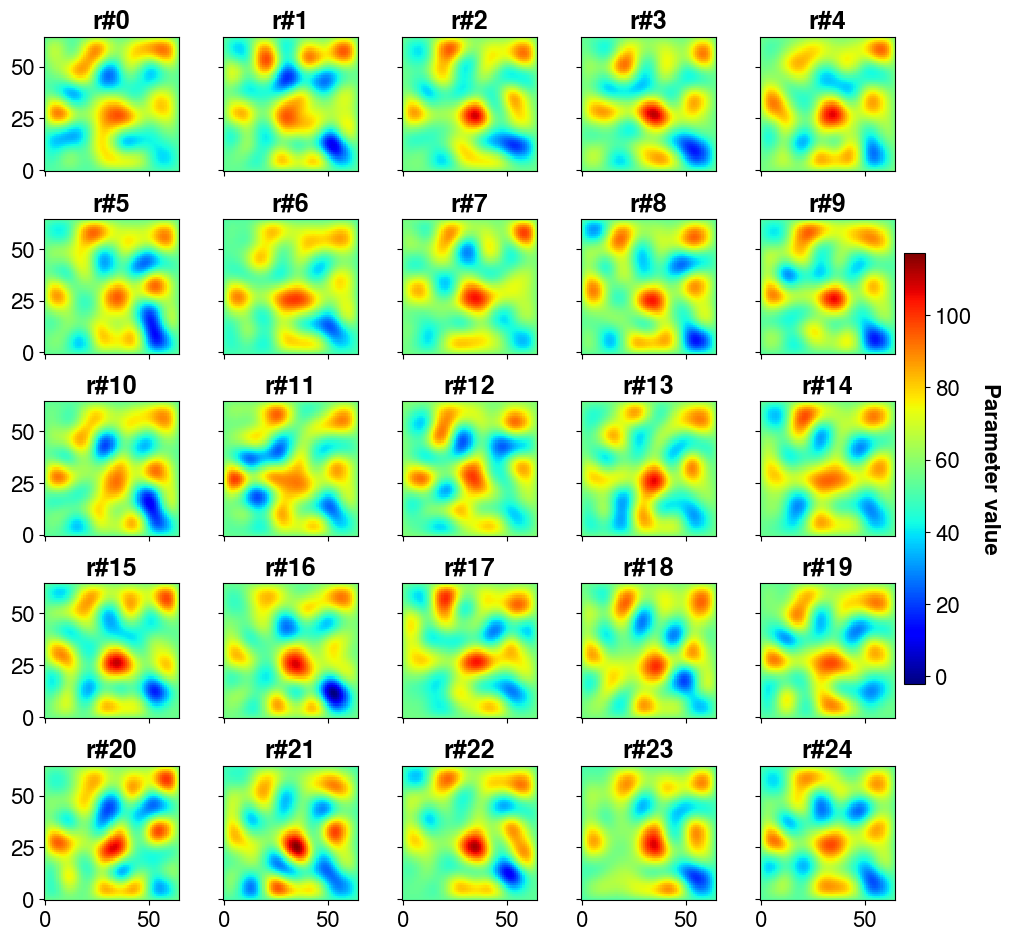

In [25]:
nrows = 5
ncols = 5
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 9.3), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder(
        [[f"ax{i}-{j}" for i in range(nrows)] for j in range(ncols)],
        sharex=True,
        sharey=True,
    ),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        f"r#{i}": post_samples[:, i].reshape(nx, ny, order="F").T
        for i in range(nrows * ncols)
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("jet"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01, shrink=0.5),
    cbar_title="Parameter value",
)

We can find the variance back from the ensemble

In [26]:
post_cov_ens = covmats.CovViaEnsemble(post_samples.T)

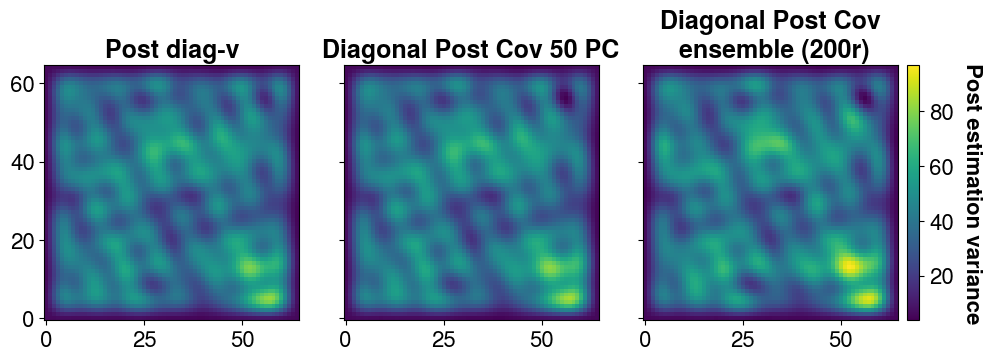

In [27]:
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 3.5), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["diag", "50pc", "ens"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        "Post diag-v": post_diagv.reshape(nx, ny, order="F").T,
        "Diagonal Post Cov 50 PC": post_cov_50_pc.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
        "Diagonal Post Cov\n ensemble (200r)": post_cov_ens.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("viridis"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01),
    cbar_title="Post estimation variance"
)

In [28]:
((post_cov_50_pc._v.T * np.sqrt(post_cov_50_pc._w))).shape

(50, 4225)

In [29]:
(np.ones((100, 50)) @ (post_cov_50_pc._v.T * np.sqrt(post_cov_50_pc._w))).shape

(100, 4225)

In [30]:
np.sum(((post_cov_50_pc._v.T * np.sqrt(post_cov_50_pc._w)) ** 2), axis=0)

array([5.66661079, 5.72174928, 6.03939978, ..., 7.45848221, 6.71797863,
       6.18563887], shape=(4225,))

In [31]:
# # Compute the inverse square root of the eigenvalue matrix
# W_inv_sqrt = np.diag(1.0 / np.sqrt(w))  # (k, k)

# # Whitening transformation
# whitened_x = x @ (v @ W_inv_sqrt)